MB_MW: miền bắc

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [64]:
pd.set_option("display.float_format", "{:,.0f}".format)

# Load CSV
df = pd.read_csv("./dataset/VN_Energy.csv")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"]) 
df = df.set_index("date")

In [65]:
df.columns

Index(['MB_MW', 'MT_MW', 'MN_MW', 'HT_MW'], dtype='object')

In [66]:
df.shape

(38688, 4)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38688 entries, 2021-01-01 00:00:00 to 2025-05-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MB_MW   38688 non-null  float64
 1   MT_MW   38688 non-null  float64
 2   MN_MW   38688 non-null  float64
 3   HT_MW   38688 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


In [68]:
df.describe()

,MB_MW,MT_MW,MN_MW,HT_MW
count,"38,688","38,688","38,688","38,688"
mean,"14,956","3,056","14,243","32,255"
std,"2,969",689,"2,720","5,805"
min,"5,459",648,"5,116","12,897"
25%,"12,882","2,555","12,281","28,189"
50%,"14,904","3,028","14,311","32,334"
75%,"16,949","3,537","16,244","36,407"
max,"25,775","5,891","22,584","50,032"


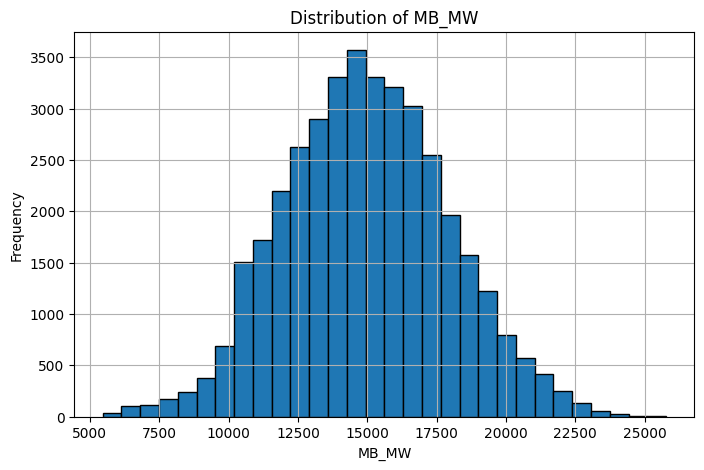

In [69]:
col = 'MB_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

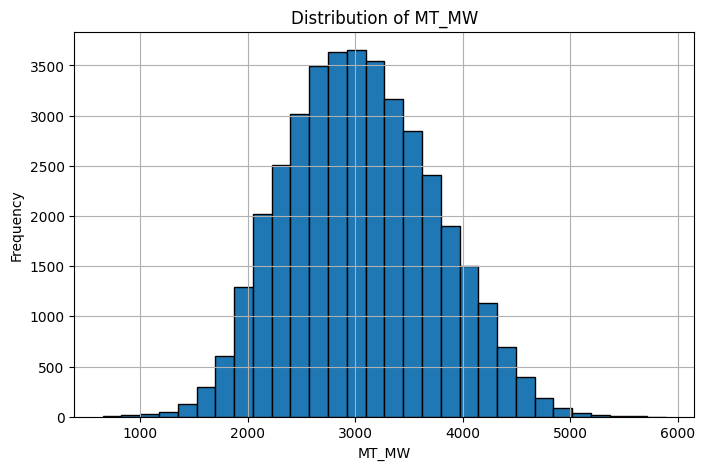

In [70]:
col = 'MT_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

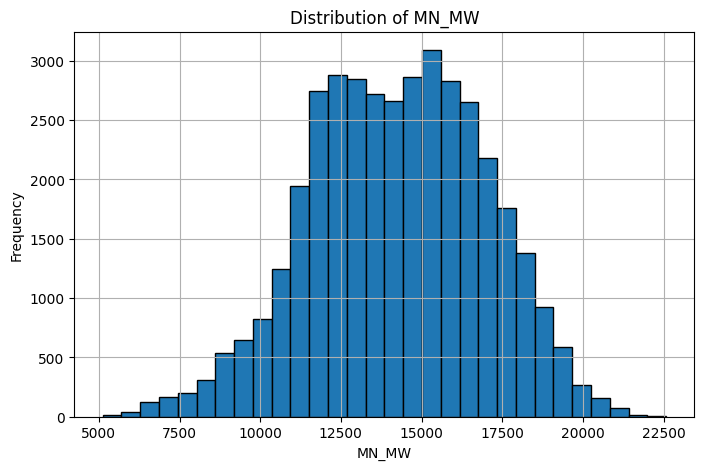

In [71]:
col = 'MN_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_7864\1286020358.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_sum = df.resample("Y").sum()


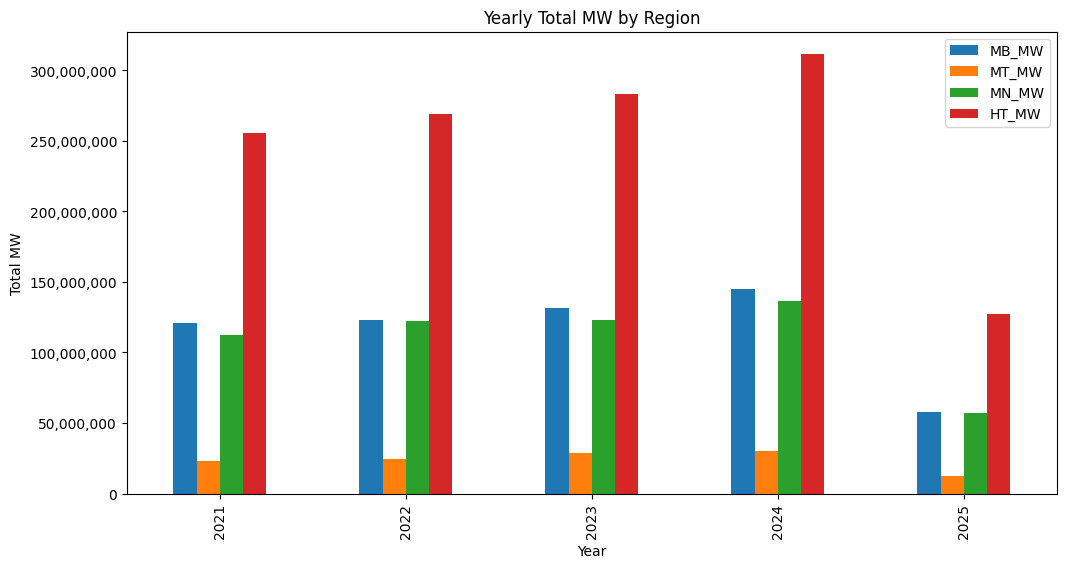

In [72]:
# Group by year and sum
df_yearly_sum = df.resample("Y").sum()
df_yearly_sum.index = df_yearly_sum.index.year

ax = df_yearly_sum.plot(kind="bar", figsize=(12,6))
plt.title("Yearly Total MW by Region")
plt.xlabel("Year")
plt.ylabel("Total MW")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_7864\4107936705.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_avg = df.resample("Y").mean()


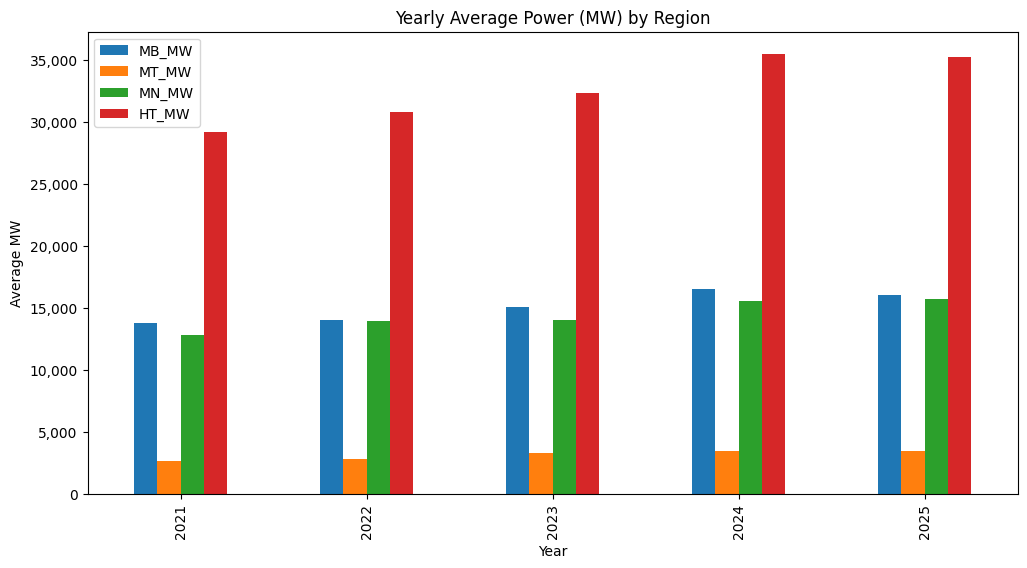

In [73]:
df_yearly_avg = df.resample("Y").mean()
df_yearly_avg.index = df_yearly_avg.index.year

ax = df_yearly_avg.plot(kind="bar", figsize=(12,6))
ax.set_title("Yearly Average Power (MW) by Region")
ax.set_xlabel("Year")
ax.set_ylabel("Average MW")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # no scientific notation
plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_7864\1457046368.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").sum()


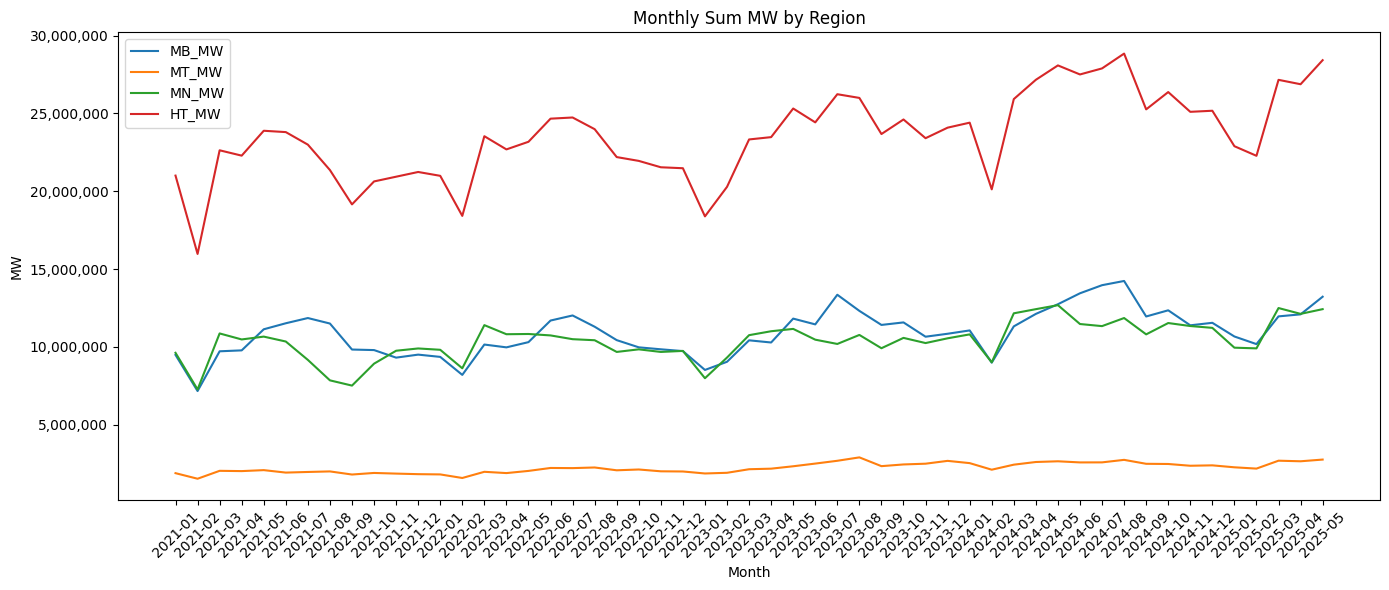

In [74]:
# Monthly cumulative (summing each month)
df_monthly = df.resample("M").sum()
df_monthly.index = df_monthly.index.to_period("M")

# Plot as line chart
fig, ax = plt.subplots(figsize=(14,6))
for col in df_monthly.columns:
    ax.plot(df_monthly.index.astype(str), df_monthly[col], label=col)

ax.set_title("Monthly Sum MW by Region")
ax.set_xlabel("Month")
ax.set_ylabel("MW")

# Format y-axis without scientific notation, add thousands separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_7864\3306824259.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").mean()


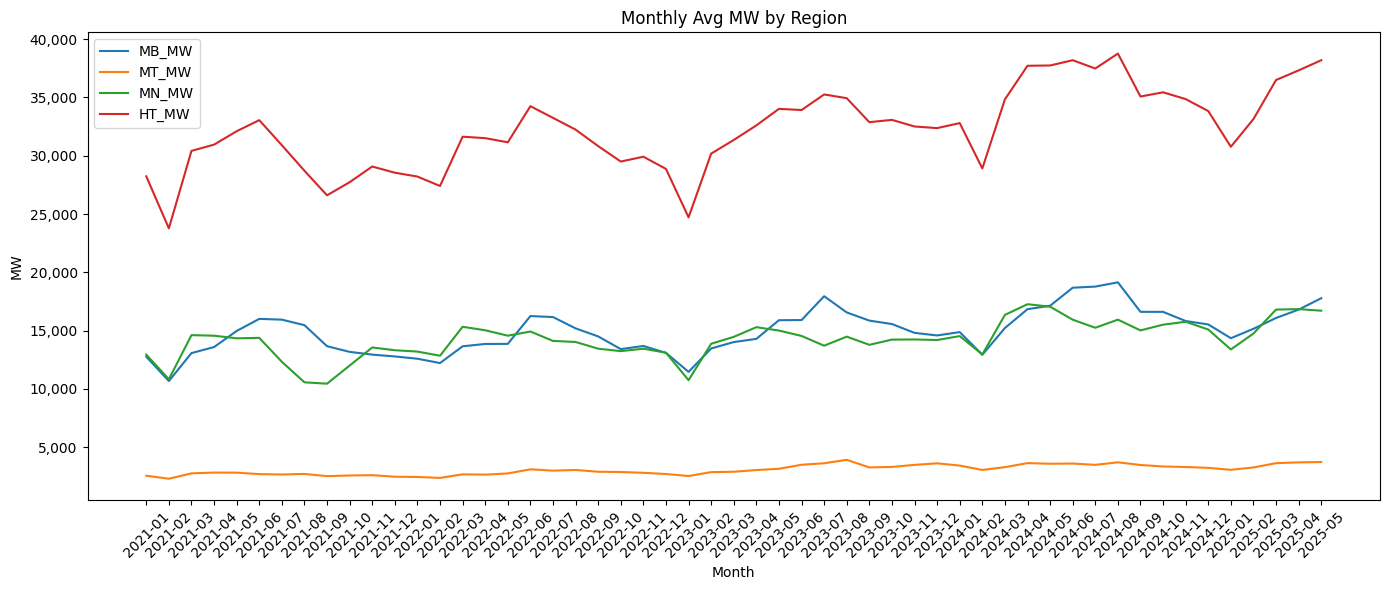

In [75]:
# Monthly cumulative (summing each month)
df_monthly = df.resample("M").mean()
df_monthly.index = df_monthly.index.to_period("M")

# Plot as line chart
fig, ax = plt.subplots(figsize=(14,6))
for col in df_monthly.columns:
    ax.plot(df_monthly.index.astype(str), df_monthly[col], label=col)

ax.set_title("Monthly Avg MW by Region")
ax.set_xlabel("Month")
ax.set_ylabel("MW")

# Format y-axis without scientific notation, add thousands separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
df = pd.read_csv("./results/VN_Energy_4320_720_20_PatchTST_VN_Energy_ftM_sl4320_ll48_pl720_dm16_nh4_el3_dl1_df128_fc1_ebtimeF_dtTrue_Exp_0/rolling_pred_4320_720_until_2030-10-31.csv")

In [77]:
df.shape

(47520, 5)

In [78]:
df[:-1]

,date,MB_MW,MT_MW,MN_MW,HT_MW
0,2025-06-01 00:00:00,"16,962","3,518","15,006","35,648"
1,2025-06-01 01:00:00,"15,912","3,356","14,262","33,665"
2,2025-06-01 02:00:00,"15,527","3,134","13,097","31,972"
3,2025-06-01 03:00:00,"14,975","3,064","12,827","30,938"
4,2025-06-01 04:00:00,"14,827","3,098","12,692","30,547"
...,...,...,...,...,...
47514,2030-11-01 18:00:00,"20,582","4,437","17,428","44,478"
47515,2030-11-01 19:00:00,"21,452","4,632","18,265","46,186"
47516,2030-11-01 20:00:00,"21,822","4,735","18,386","46,451"
47517,2030-11-01 21:00:00,"21,791","4,758","18,125","45,834"


In [79]:
df.head()

,date,MB_MW,MT_MW,MN_MW,HT_MW
0,2025-06-01 00:00:00,"16,962","3,518","15,006","35,648"
1,2025-06-01 01:00:00,"15,912","3,356","14,262","33,665"
2,2025-06-01 02:00:00,"15,527","3,134","13,097","31,972"
3,2025-06-01 03:00:00,"14,975","3,064","12,827","30,938"
4,2025-06-01 04:00:00,"14,827","3,098","12,692","30,547"


In [80]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract year
df["year"] = df["date"].dt.year

# Drop original HT_MW
df = df.drop(columns=["HT_MW"])

# Sum MW columns by year
df_yearly_sum = df.groupby("year")[["MB_MW", "MT_MW", "MN_MW"]].sum()

# Recompute HT_MW as sum of the 3 columns
df_yearly_sum["HT_MW"] = df_yearly_sum[["MB_MW", "MT_MW", "MN_MW"]].sum(axis=1)

In [83]:
df_yearly_sum.head(100)

,MB_MW,MT_MW,MN_MW,HT_MW
year,,,,
2025,"104,893,076","21,529,506","75,307,549","201,730,132"
2026,"181,692,448","40,551,563","127,939,159","350,183,170"
2027,"186,096,676","42,293,709","140,037,888","368,428,273"
2028,"186,223,638","41,796,810","144,828,076","372,848,524"
2029,"179,790,683","39,958,941","141,374,680","361,124,304"
2030,"141,750,263","31,171,741","112,613,469","285,535,473"


In [84]:
print(df_yearly_sum[["HT_MW"]].head(100))

           HT_MW
year            
2025 201,730,132
2026 350,183,170
2027 368,428,273
2028 372,848,524
2029 361,124,304
2030 285,535,473
